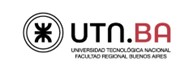

###**Trabajo Semanal 3**
**Teoria de los Circuitos 2**


Autor: Alan Nicolas Parizek


Profesor: Mariano Llamedo Soria  
Ayudante de TPs: David Moharos  
Jefe de TPs: César Fuoco  




###Consignas


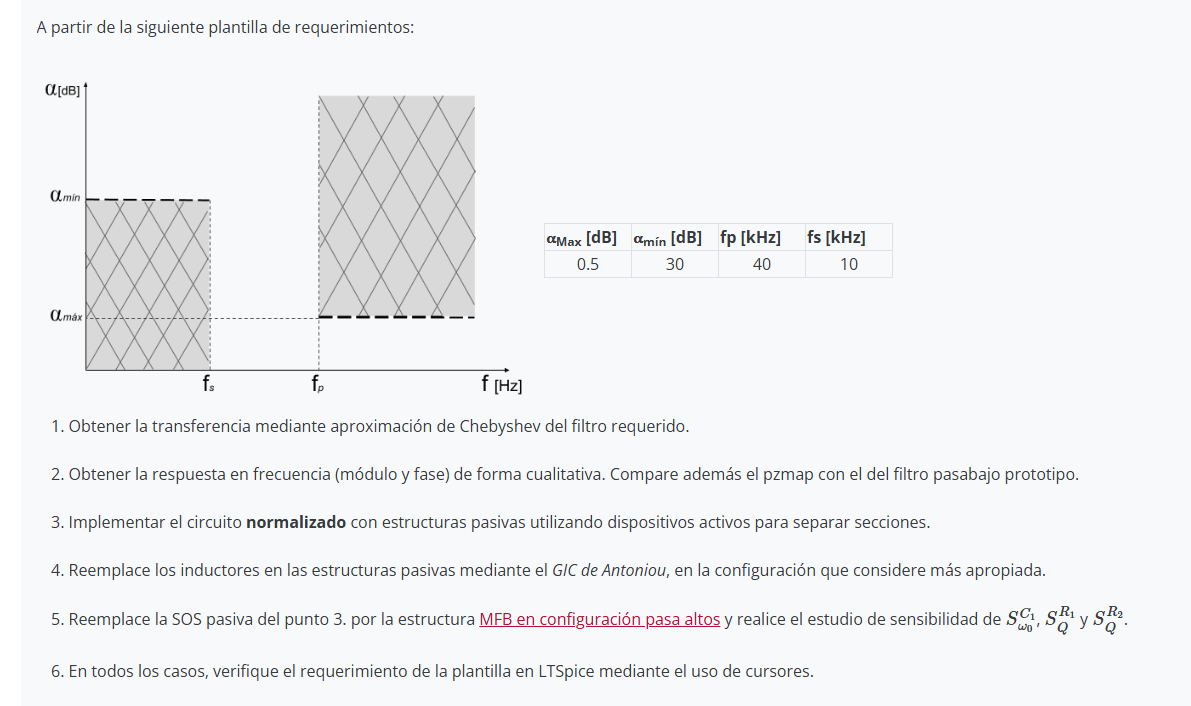

###Imports

In [2]:
import sympy as sp
import numpy as np
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pretty_print_SOS, tf2sos_analog
import scipy.signal as sig

In [3]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq
from pytc2.general import print_latex, a_equal_b_latex_s

# módulo de SciPy
from scipy import signal as sig

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

###Desarrollo

Primero, obtengo la transferencia objetivo planteando un prototipo pasa-bajos.

Normalizo Fp a 1 y Fs a 0.25

$$\xi^{2}=10^{\frac{\alpha_{max}}{10}}-1=0,122$$

$$\alpha_{min}=10 \log(1+\xi^{2}\cosh^{2}(n \cdot \cosh^{-1}(w_{s})) \Rightarrow \alpha_{min}=38,6 \text{ con } n=3$$

$$|T|^{2}=\frac{1}{1+\xi^{2}C_{n}^{2}(\omega)}$$

$$C_{2}=2\omega^{2}-1$$

$$C_{3}=4\omega^{3}-2\omega-\omega$$

$$C_{3}=4\omega^{3}-3\omega; \quad {C_{3}}^{2}=16\omega^{6}-24\omega^{4}+9\omega^{2}$$

$$|T|^{2}=\frac{1}{16\xi^{2}\omega^{6}-24\xi^{2}\omega^{4}+9\xi^{2}\omega^{2}+1}$$

Paso de $\omega$ a S con $\omega=\frac{S}{j}$, ademas, uso como variable objetivo:

$$$=\frac{1}{S}$$

$$|T($)|^{2}=\frac{\frac{1}{16}s^{6}}{-s^{6}-\frac{3}{2}s^{4}-\frac{9}{16}s^{2}+\frac{1}{16\xi^{2}}}$$

$\quad \frac{1}{16\xi^{2}}=0,5122$

Obtengo las raíces de forma numérica con Python:

$$T($)=\frac{0,7156}{(\phi+0,6265)(\phi+0,3132+1,0219j)(\phi+0,3132-1,0219j)}$$

$$T($)=\frac{0,7156}{(\phi+0,6265)(\phi^{2}+0,6264\phi+1,1418)}$$

$$T($)=\frac{0,7156}{\phi^{3}+1,2529\phi^{2}+1,5346\phi+0,7156}$$

Aplico la transformación ($$ = \frac{1}{s}$)

$$T(s)=\frac{0,7156}{\frac{1}{s^{3}}+1,2529\frac{1}{s^{2}}+1,5346\frac{1}{s}+0,7156}$$

$$T(s)=\frac{0,7156 s^{3}}{s^{3}+1,2529 s^{2}+1,5346s+0,7156}$$

$$T(s)=\frac{s^{3}}{s^{3}+1,7508 s^{2}+2,1444s+1} = \frac{s \cdot 1,155}{s+0,7156} \cdot \frac{0,865 s^{2}}{s^{2}+\frac{1,155}{1,141}s+1,1852}$$

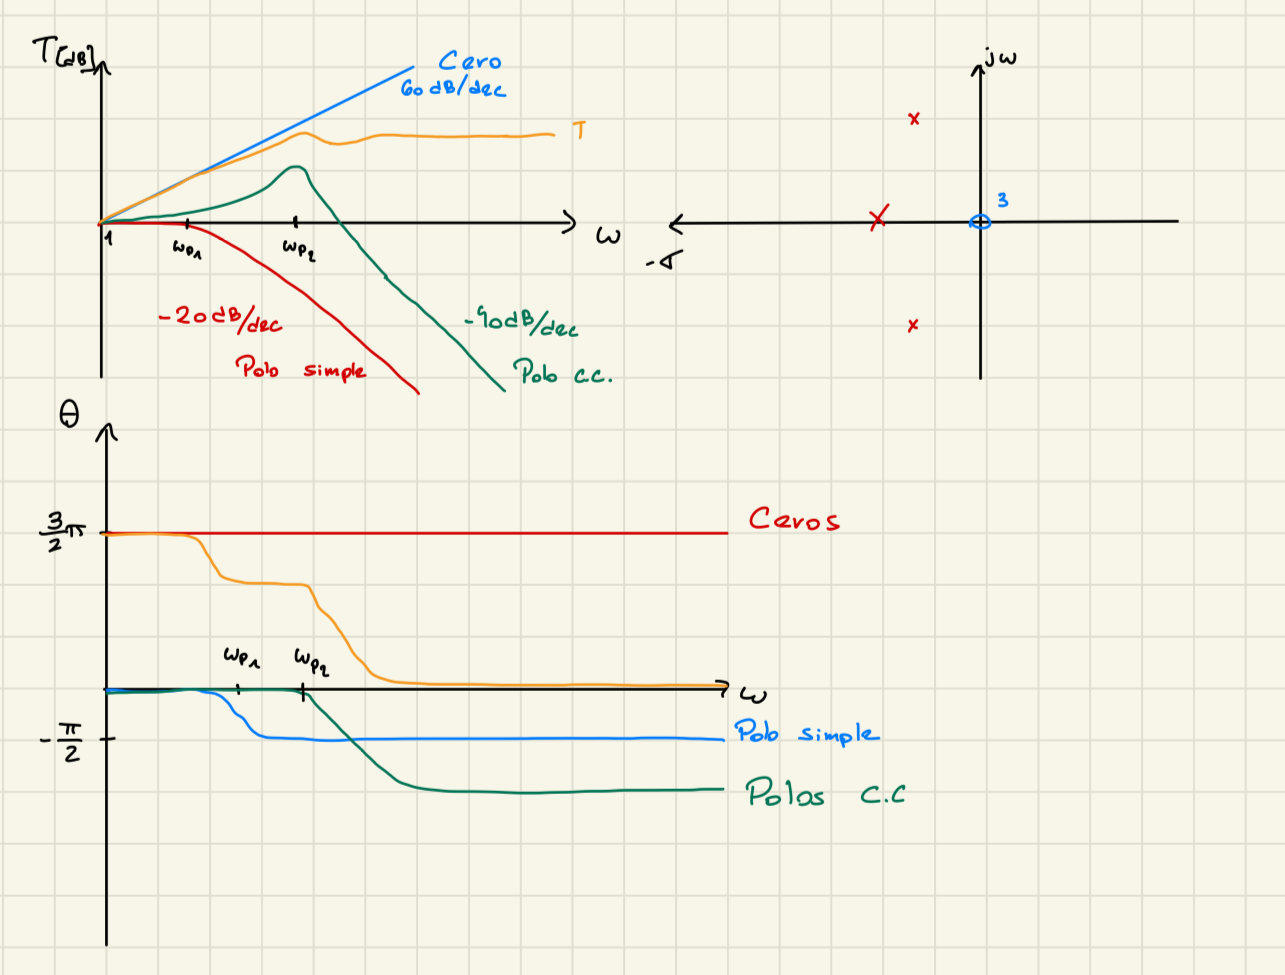

En este caso, se toma la Wo del filtro de grado 1 y la misma de la SOS como distintos, por eso se ve en escalon en el gráfico de fase y dos pendientes distintas en el módulo.


Con el codigo que sigue se puede ver como se buscan las raices del polinomio grado 6 obtenido analiticamente y luego se guardan las raices del semiplano izquierdo. Ademas, se buscan los coeficientes de la transferencia para comparar resultados.

In [4]:
#calculo las raices de mi t(s)
raices = np.roots([-1,0,-3/2,0,-9/16,0,0.5122])

raices_spi = raices[np.real(raices) < 0]



print("Raices del Denominador: ", raices_spi)
den_from_poles = np.poly(raices_spi)

print("coeficientes de la transferencia: ", den_from_poles)


Raices del Denominador:  [-0.31322505+1.02192456j -0.31322505-1.02192456j -0.62645011+0.j        ]
coeficientes de la transferencia:  [1.         1.25290021 1.53487947 0.71568149]


Nuevamente, se usa simulacion para comparar resultados. En este caso, con simpy se pueden obtener las SOS de la transferencia.  En el primer caso se ve la transferencia obtenida y en el segundo la misma normalizada a wo=1

In [5]:
ripple = 0.5
orden = 3

z, p, k = sig.cheb1ap(orden, ripple)

eps =np.sqrt(10**(ripple/10)-1)
num, den = sig.zpk2tf(z,p,k)

sos_lp = tf2sos_analog(num, den)
pretty_print_SOS(sos_lp, mode = "omegayq")

den_from_poles = np.poly(z)

print(den_from_poles)

<IPython.core.display.Math object>

1.0


In [6]:
num_hp = [1, 0, 0, 0]
den_hp = [1, 1.7508, 2.1448, 1]

sos_hp = tf2sos_analog(num_hp, den_hp)
pretty_print_SOS(sos_hp, mode = "omegayq")

<IPython.core.display.Math object>

A continuacion, se muestran los resultados numericos de Magnitud, fase y diagrama de polos y ceros.

Se normalizan las transferencias de las SOS para poder verificar los requerimientos de la plantilla

En w = 0.25 rad/s:
  Módulo (dB):     -35.99 dB

En w = 1.0 rad/s:
  Módulo (dB):     -0.39 dB



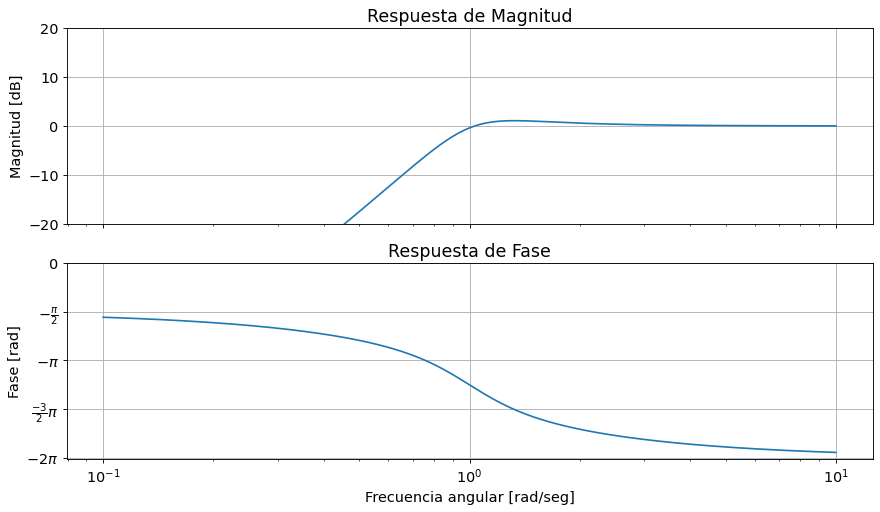

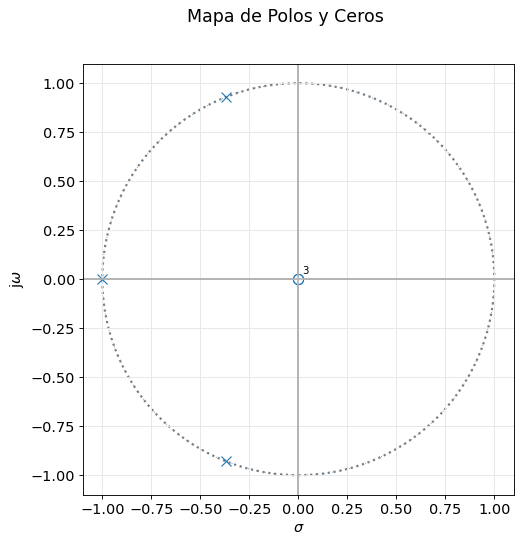

In [12]:
#num= np.array([1, 0, 0, 0])
#den = np.array([1, 1.7508, 2.1448, 1])
num1 = np.array([1, 0])
den1 = np.array([1, 1])

numSOS = [1, 0, 0]
denSOS = [1, 0.7395, 1]

num = np.convolve(num1, numSOS)
den = np.convolve(den1, denSOS)

TF = sig.TransferFunction(num, den)

_, axes_hdl = bodePlot(TF)

plt.sca(axes_hdl[0])
plt.ylim(-20, 20)
pzmap(TF)

##verifico requerimientos de plantilla

frecuencias_interes = np.array([0.25, 1.0])

w, h = sig.freqs(num, den, worN=frecuencias_interes)

modulo_absoluto = np.abs(h)
modulo_db = 20 * np.log10(modulo_absoluto)

for i in range(len(frecuencias_interes)):
    print(f"En w = {w[i]} rad/s:")
    print(f"  Módulo (dB):     {modulo_db[i]:.2f} dB\n")

Se puede notar que en la respuesta de fase, el graficador empieza por -90 en vez de 270, el cual es el mismo lugar geométrico. Tambien, la pendiente de la fase es constante, ya que las Wo de las dos secciones estan normalizadas a 1.

Ahora, se implementa el sistema utilizando circuitos pasivos.

SOS:

$$T(s)=\frac{0,865 s^{2}}{s^{2}+\frac{1,155}{1,141}s+1,1852}=\frac{0,616s^{2}}{s^{2}+s \cdot 0,7385+1}$$

$$T = \frac{sL}{sL+\frac{1}{sC}+R}=\frac{s^{2}LC}{s^{2}LC+sCR+1}=\frac{s^{2}}{s^{2}+s\frac{R}{L}+\frac{1}{LC}}$$

Con $\omega_{0}=1 \rightarrow T=\frac{s^{2}}{s^{2}+s\frac{R}{L}+\frac{1}{LC}}$$

Con $\Omega_{\omega}=\sqrt{\frac{1}{LC}} \rightarrow T(s)=\frac{s^{2}}{s^{2}+\sqrt{\frac{C}{L}} s+1}$

$$\sqrt{\frac{L}{C}}=Q \text{ }; \quad L=CQ^{2} \text{ y } L=\frac{1}{C}$$

$$C=\frac{1}{Q}; \quad L=Q$$

Seccion Orden 1:

$$T(s)=\frac{sL}{sL+R}=\frac{s}{s+\frac{R}{L}}$$

Normalizo con $$ $ = S \frac{R}{L}$$

$$T($)=\frac{$}{$+1}$$

$$\frac{R}{L}=\omega_{0}; \quad R=\omega_{0}L$$

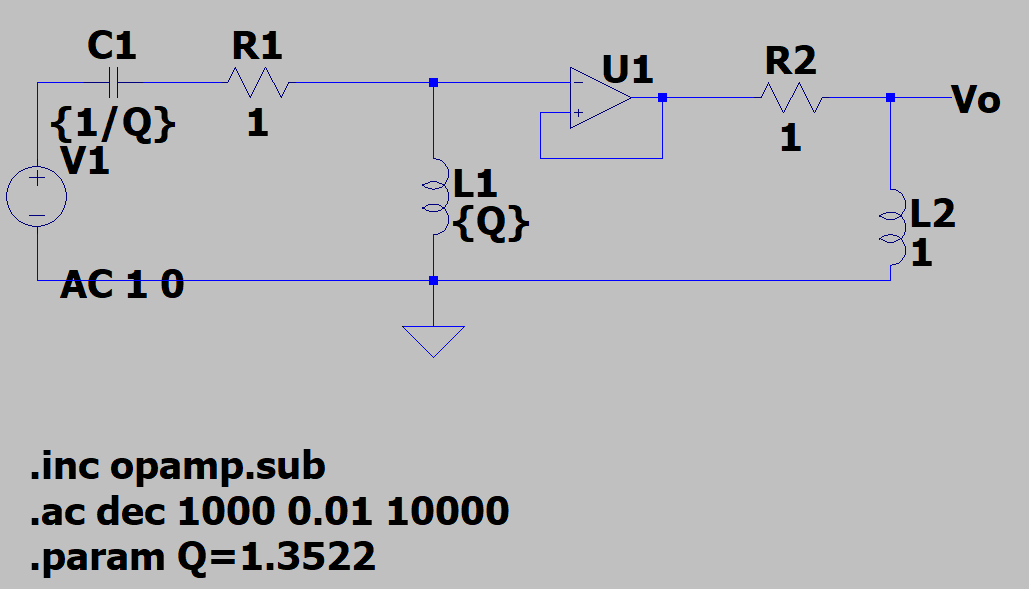

Respuesta de modulo y fase:

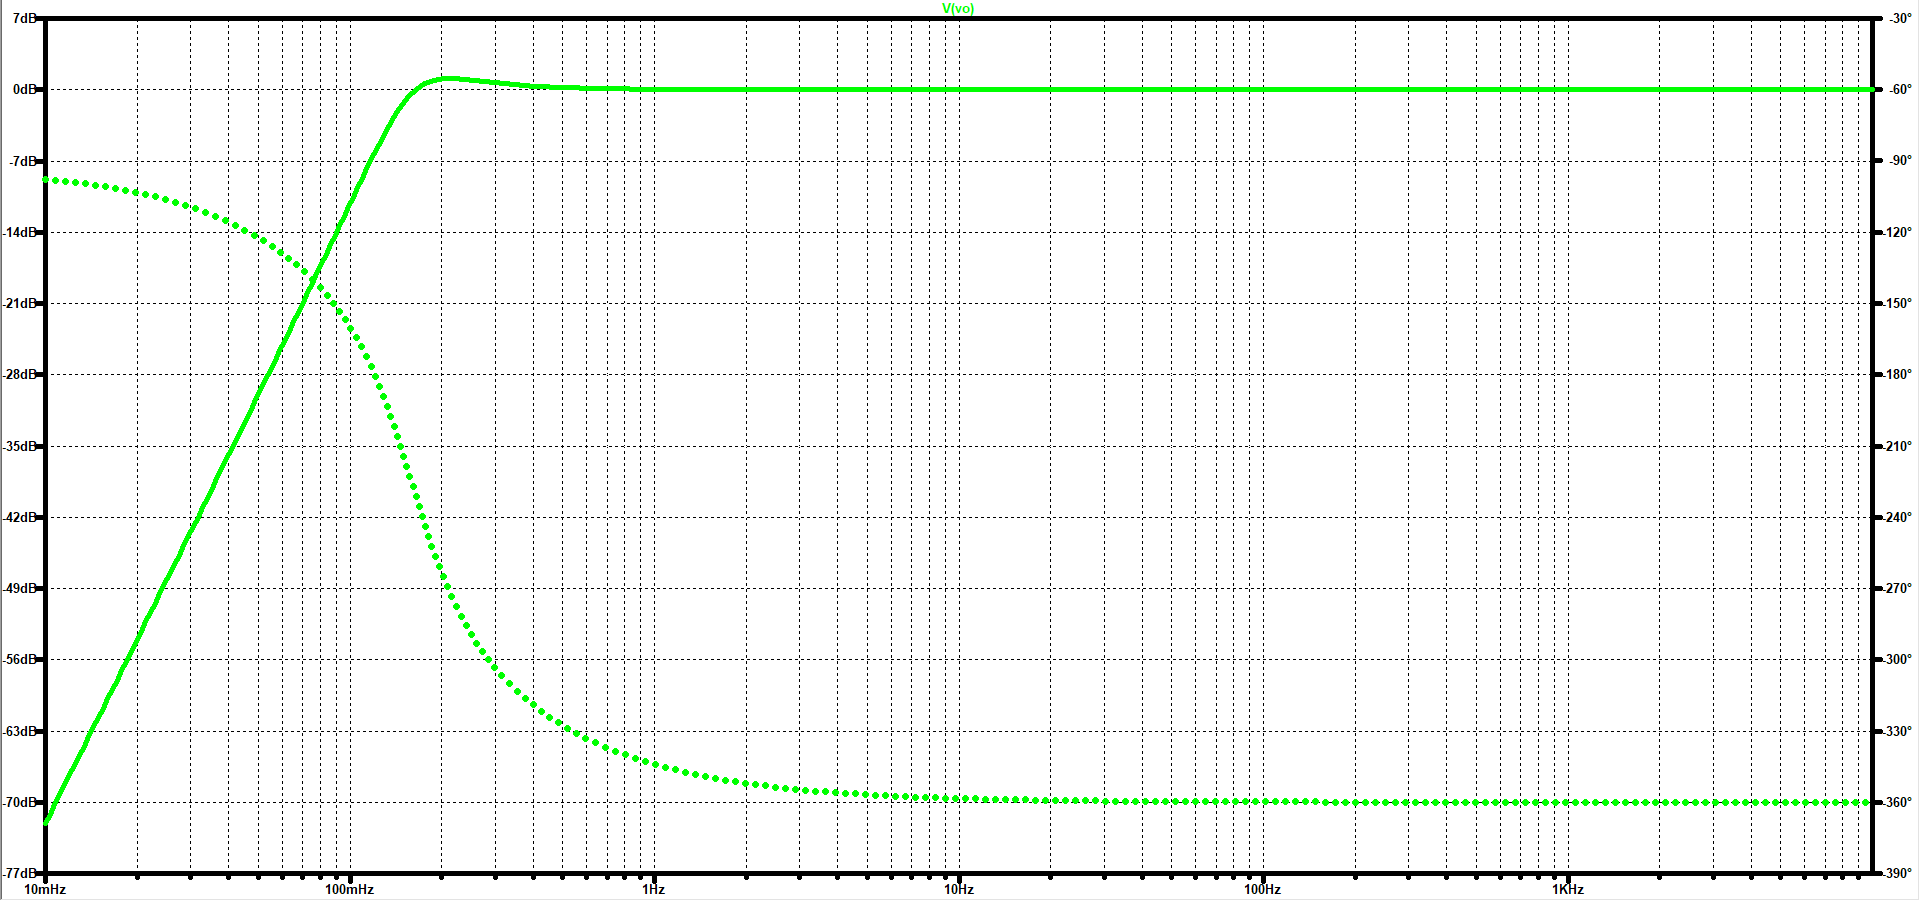

Se puede notar que es comparaable con los resultados cualitativos y numericos.

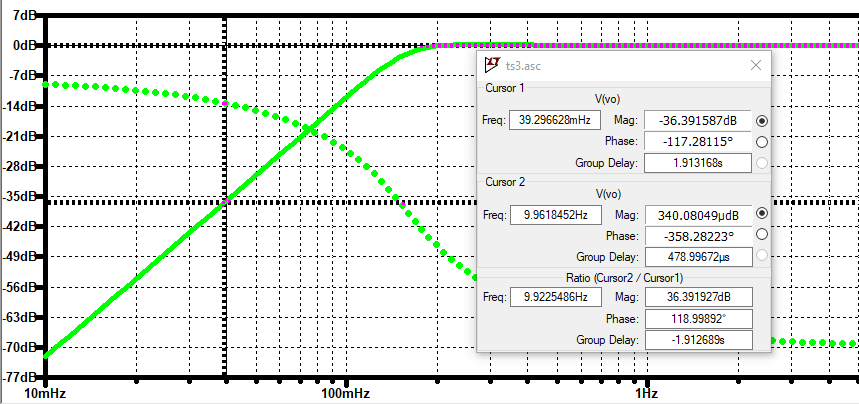

El objetivo de alfa_min era de -30dB para 0.25 la Wo. Si Wo=159mHz, tiene que haber al menos -30dB en 0,3975mHz, lo cual se cumple.

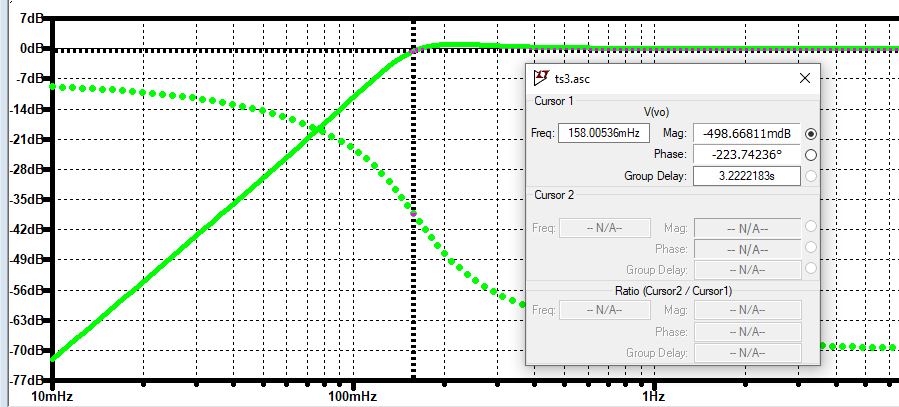

Tambien se puede notar el ripple de 0,5 en Wo.

Ahora reemplazo los inductores por GICs.

$$Z_{GIC_{1}}=s R^{2} C_{1} = Q \Rightarrow C_{1}=\frac{Q}{R^{2}}$$

$$Z_{GIC_{2}}=s R^{2} C_{2} = \frac{R}{\omega_{0}} \Rightarrow C_{2}=\frac{1}{R\omega_{0}}$$

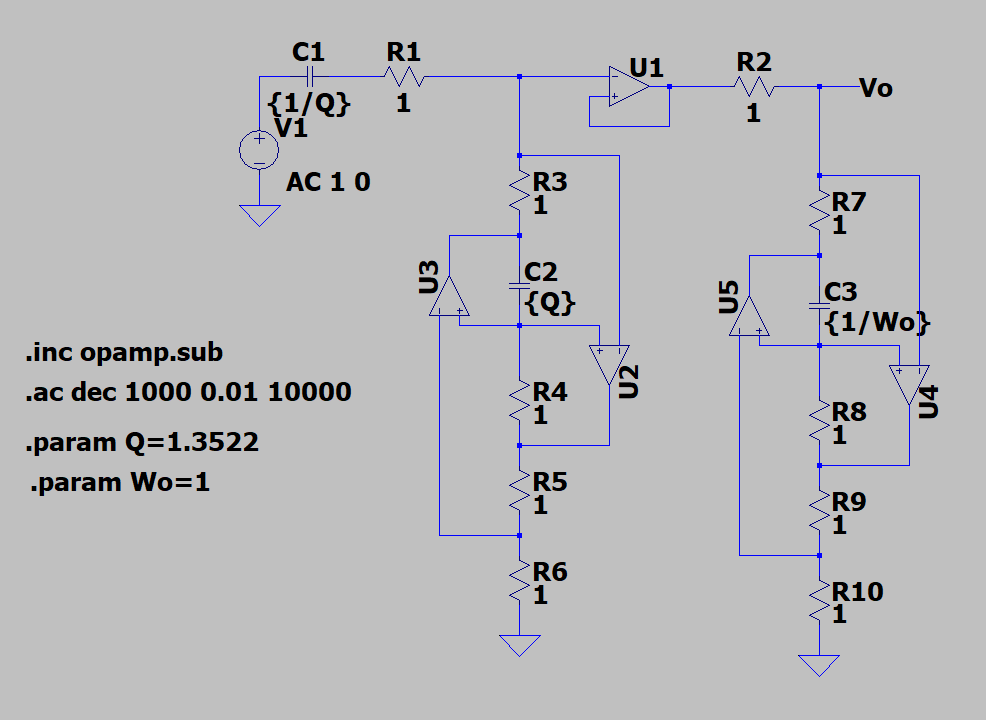

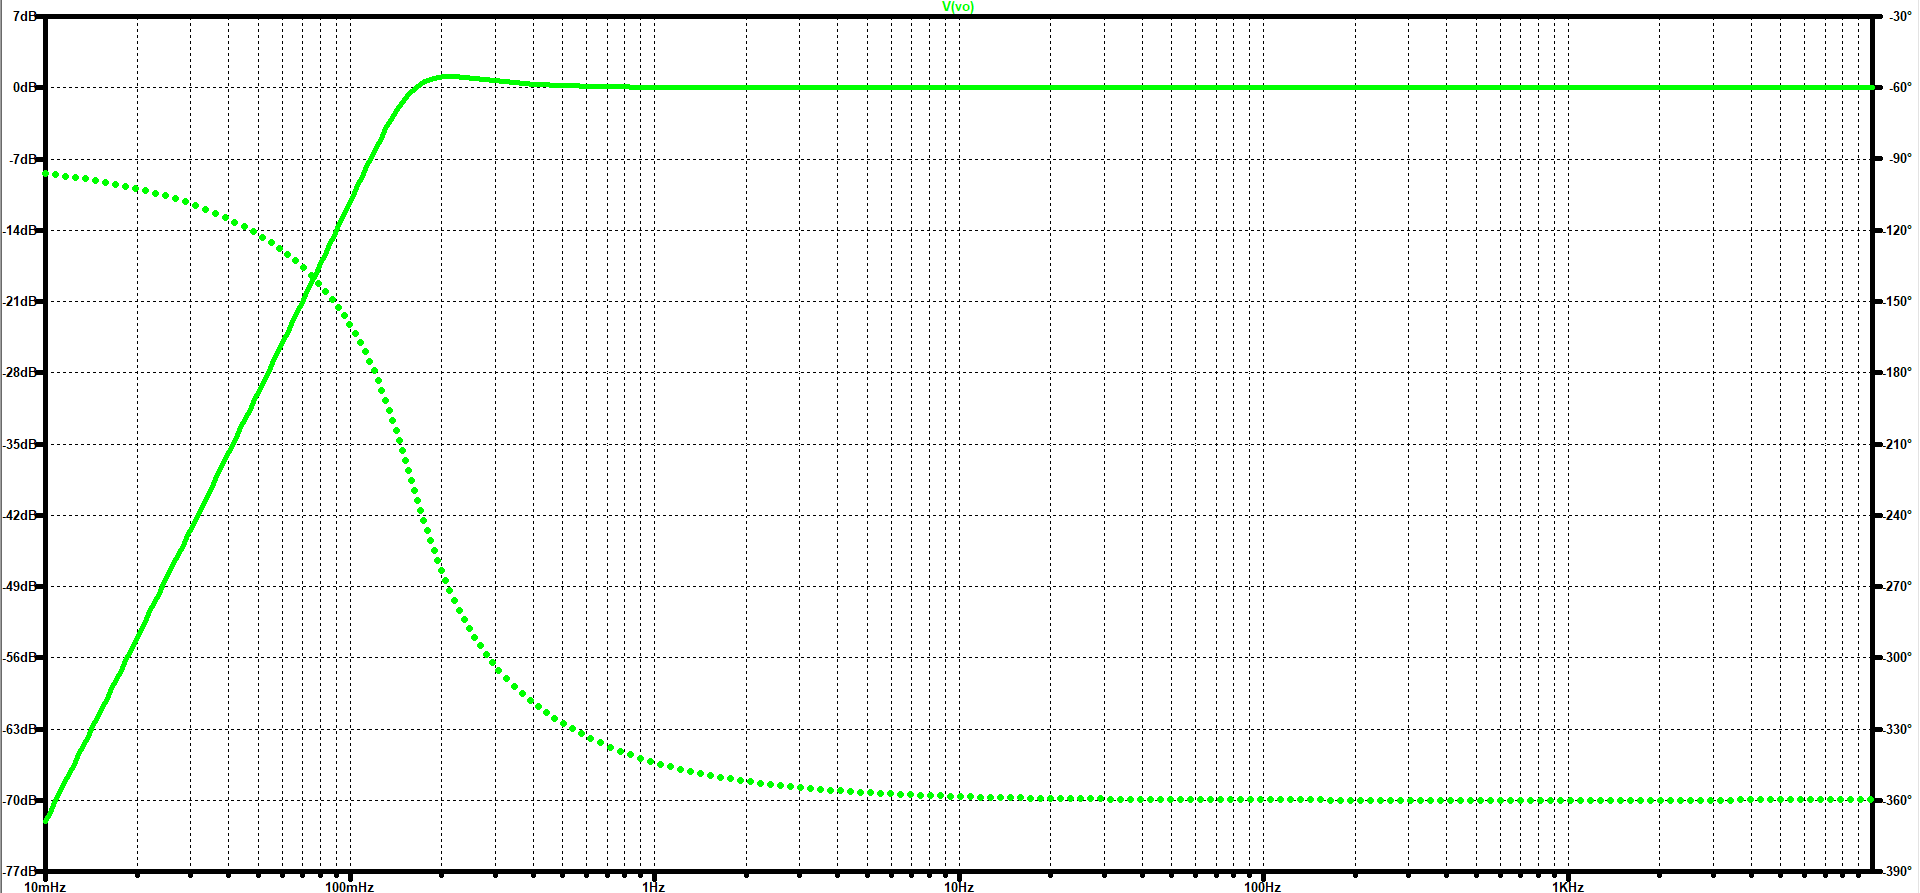

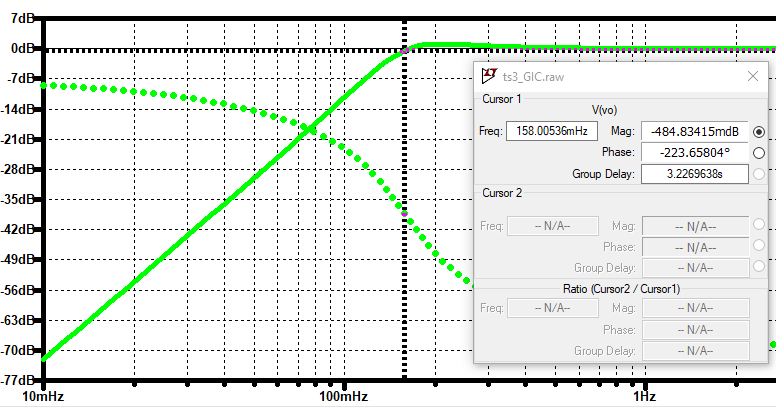

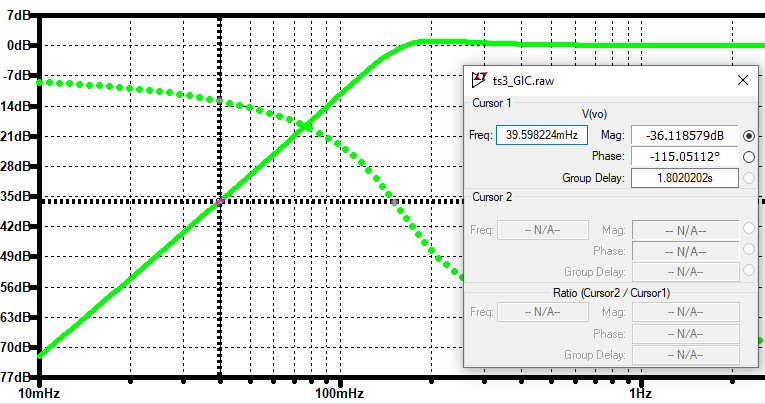

Se puede observar que los resultados son los mismos.

Ahora, se reemplaza la SOS con un MFB pasa-altos.

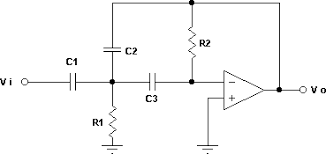

* **Nodo $V_a$**:
    $$(sC_{1}+sC_{2}+sC_{3}+G_{1})V_{a}-V_{i}sC_{3}-V_{0}sC_{1}-V_{b}sC_{2} = 0$$
* **Nodo $V_b$**:
    $$(sC_{2}+G_{2})V_{b}-V_{a}sC_{2}-V_{0}G_{2}=0$$

Como $V_{b}=0$:

$$V_{a}=-V_{0}\frac{G_{2}}{s C_{2}}$$

$$-V_{0}\frac{G_{2}}{sC_{2}}(sC_{1}+sC_{2}+sC_{3}+G_{1})-V_{i}sC_{3}-V_{0}sC_{1}=0$$

$$-V_{0} \left[ \frac{s^{2}C_{1}C_{2}+sG_{2}(C_{1}+C_{2}+C_{3})+G_{1}G_{2}}{sC_{2}} \right] = V_{i}sC_{3}$$

$$H(s)=\frac{-s^{2}C_{2}C_{3}}{s^{2}C_{1}C_{2}+sG_{2}(C_{1}+C_{2}+C_{3})+G_{1}G_{2}}$$

$$H(s)=\frac{-s^{2}\frac{C_{3}}{C_{1}}}{s^{2}+s\frac{G_{2}}{C_{1}C_{2}}(C_{1}+C_{2}+C_{3})+\frac{G_{1}G_{2}}{C_{1}C_{2}}}$$

Si $C_{1}=C_{2}=C_{3}=C=1$:

$$H(s)=\frac{-s^{2}}{s^{2}+s \cdot 3G_{2}+G_{1}G_{2}}$$

$$H(s)=-\frac{s^{2}}{s^{2}+s \cdot 3\sqrt{\frac{G_{2}}{G_{1}}}+1}$$

$$Q=1,3543$$

$$3\sqrt{\frac{G_{2}}{G_{1}}}=\frac{1}{Q}$$

$$G_{1}G_{2}=1 \rightarrow R_{1}=\frac{1}{R_{2}}$$

$$\sqrt{\frac{R_{1}}{R_{2}}}=\frac{1}{3Q} \Rightarrow \frac{R_{1}}{R_{2}}=\frac{1}{9Q^{2}}$$

$$R_{1}=\frac{R_{2}}{9Q^{2}} \rightarrow \frac{1}{R_{2}}=\frac{R_{2}}{9Q^{2}}$$

$$3Q=R_{2} \Rightarrow R_{2}=4,0629$$

$$R_{1}=0,2461$$

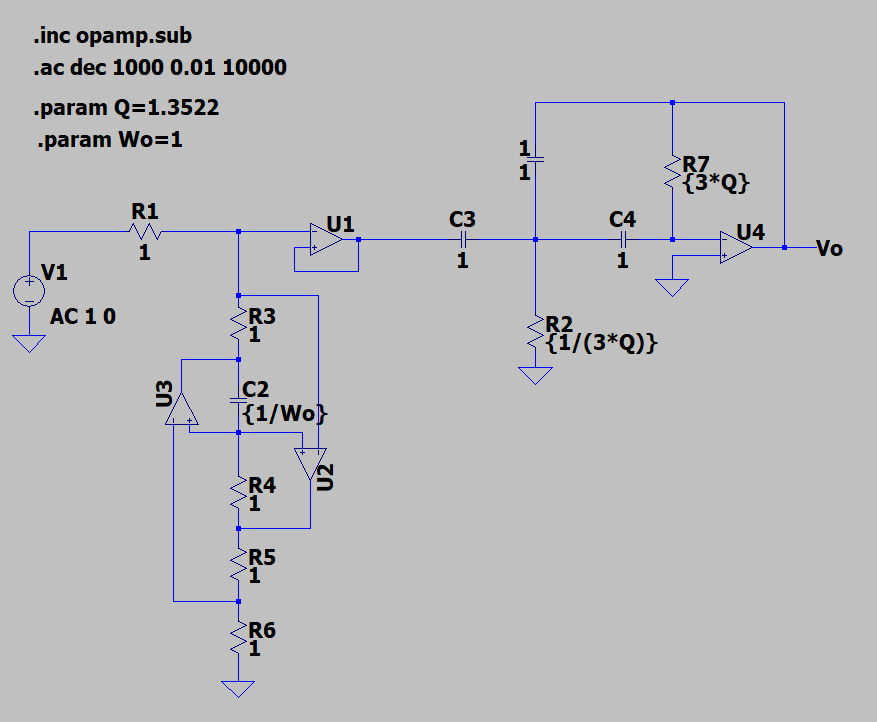

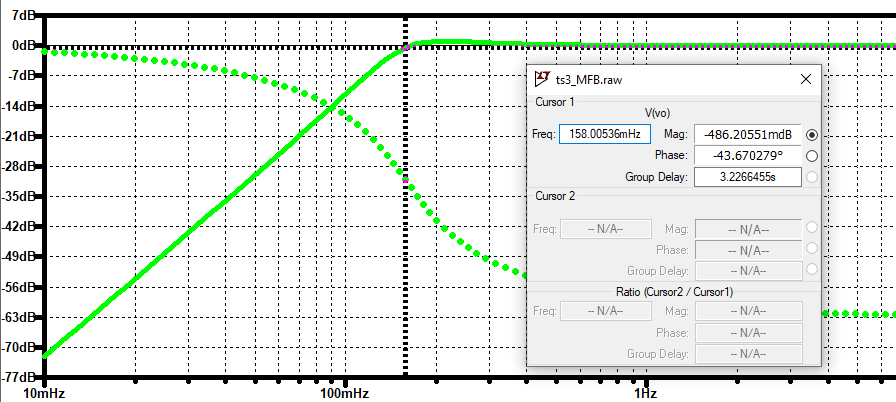

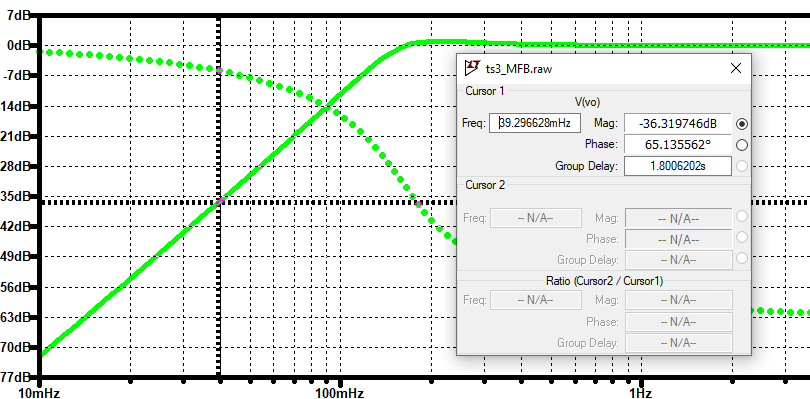

Se pueden ver los mismos resultados obtenidos con los dos circuitos anteriores.

###Sensibilidad de los parametros



$$\omega_{0}=\sqrt{\frac{1}{C_{1}C_{2}R_{1}R_{2}}}$$

$$\frac{d\omega_{0}}{dC_{1}}=-\frac{1}{2 C_{1}^{2} C_{2} R_{1} R_{2} \sqrt{\frac{1}{C_{1}C_{2}R_{1}R_{2}}}}$$

$$S_{C_{1}}^{\omega_{0}}=\frac{C_{1}}{\sqrt{\frac{1}{C_{1}C_{2}R_{1}R_{2}}}} \left( -\frac{1}{2 C_{1}^{2} C_{2} R_{1} R_{2} \sqrt{\frac{1}{C_{1}C_{2}R_{1}R_{2}}}} \right)$$

$$\boxed{S_{C_{1}}^{\omega_{0}}=\frac{1}{2}}$$

$$\frac{\omega_{0}}{Q} = \frac{G_{2}}{C_{1}C_{2}}(C_{1}+C_{2}+C_{3})$$

$$\frac{\sqrt{\frac{1}{R_{1}R_{2}C_{1}C_{2}}}}{Q}=\frac{1}{R_{2}C_{1}C_{2}}(C_{1}+C_{2}+C_{3})$$

$$\sqrt{R_{1}R_{2}C_{1}C_{2}} \cdot Q = \frac{R_{2}C_{1}C_{2}}{C_{1}+C_{2}+C_{3}}$$

$$Q = \sqrt{\frac{R_{2}^{2}C_{1}^{2}C_{2}^{2}}{R_{1}R_{2}C_{1}C_{2}}} \frac{1}{C_{1}+C_{2}+C_{3}}$$

$$Q = \sqrt{\frac{R_{2}C_{1}C_{2}}{R_{1}}} \frac{1}{C_{1}+C_{2}+C_{3}}$$

$$\frac{dQ}{dR_{1}} = \frac{\sqrt{R_{2}C_{1}C_{2}}}{C_{1}+C_{2}+C_{3}} \left( -\frac{1}{2 R_{1}^{3/2}} \right)$$


$$S_{R_{1}}^{Q} = \frac{R_{1}}{\sqrt{\frac{R_{2}C_{1}C_{2}}{R_{1}}} \frac{1}{C_{1}+C_{2}+C_{3}}} \cdot \left[ \frac{\sqrt{R_{2}C_{1}C_{2}}}{C_{1}+C_{2}+C_{3}} \left( -\frac{1}{2 R_{1}^{3/2}} \right) \right] =$$

$$= R_{1}^{1/2} \cdot \left( -\frac{1}{2 R_{1}^{3/2}} \right) = -\frac{1}{2}$$

$$\boxed{|S_{R_{1}}^{Q}| = \frac{1}{2}}$$

$$\frac{dQ}{dR_{2}} = \sqrt{\frac{C_{1}C_{2}}{R_{1}}} \frac{1}{C_{1}+C_{2}+C_{3}} \cdot \frac{1}{2\sqrt{R_{2}}}$$

$$S_{R_{2}}^{Q} = \frac{R_{2}}{\sqrt{\frac{R_{2}C_{1}C_{2}}{R_{1}}} \frac{1}{C_{1}+C_{2}+C_{3}}} \cdot \sqrt{\frac{C_{1}C_{2}}{R_{1}}} \frac{1}{C_{1}+C_{2}+C_{3}} \cdot \frac{1}{2\sqrt{R_{2}}}$$

$$\boxed{S_{R_{2}}^{Q} = \frac{1}{2}}$$